# TRACED — Usage Examples

**TRACED** (Trend-Adaptive Classification with Ellipsoidal Disambiguation) is a single-pass online classifier that learns one sample at a time without storing training data.

Each class is represented by a collection of **hyperellipsoid neurons** that grow and merge incrementally.

### Key Hyperparameters

| Parameter | Default | Description |
|-----------|---------|-------------|
| `method` | `'overlap-outside'` | Region to resolve: `'overlap'`, `'outside'`, or `'overlap-outside'` |
| `reduce_dims` | `0` | Number of PCA dimensions to drop during overlap resolution (0 = disabled) |
| `distance_metric` | `'boundary'` | Distance measure: `'boundary'` or `'center'` |
| `N0` | `3` | Minimum samples a neuron must accumulate before voting in `predict` |
| `delta` | `2` | Distance-threshold multiplier when creating a new neuron |
| `r` | `√(2π)` | Ellipsoid scale factor |
| `alpha` | `0` | Displacement smoothing (0 = no memory) |
| `beta` | `0` | Expansion smoothing (0 = no memory) |
| `width_parameter` | `1` | Blend between PCA-width and shift-width |
| `norm` | `2` | Minkowski norm (2 = Euclidean) |
| `threshold` | `15` | Angle threshold for pairing PCA axes (degrees) |

In [49]:
import numpy as np
from sklearn.datasets import load_iris, load_digits, make_classification
from sklearn.metrics import accuracy_score
from sklearn.base import clone
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from spdal import TRACED

## 1. Basic Batch Usage

Learn all training data in a single call to `partial_fit`, then predict on the test set.

In [50]:
X, y = load_iris(return_X_y=True)
X_train, X_test = X[:120], X[120:]
y_train, y_test = y[:120], y[120:]

clf = TRACED(alpha=0.2)
clf.partial_fit(X_train, y_train, classes=np.unique(y))
y_pred = clf.predict(X_test)

print(f"Classes learned : {clf.classes_}")
print(f"Neurons created : {len(clf.neuron_list)}")
print(f"Accuracy        : {accuracy_score(y_test, y_pred):.2%}")
print(f"Predictions     : {y_pred.tolist()}")

Classes learned : [0 1 2]
Neurons created : 7
Accuracy        : 100.00%
Predictions     : [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


## 2. Neuron Inspection

`clf.neuron_list` is a `list[dict]` — each neuron stores `center`, `width`, `cov`, `eig_component`, `n`, `displacement`, and `expansion`.

In [51]:
print(f"{'#':<4} {'class':<7} {'n':>5}   {'center':^32}   {'width':^32}")
print("-" * 85)
for i, n in enumerate(clf.neuron_list):
    center_str = str(np.round(n['center'], 2))
    width_str  = str(np.round(n['width'],  3))
    print(f"{i:<4} {str(n['y']):<7} {n['n']:>5}   {center_str:<32}   {width_str:<32}")

#    class       n                center                             width              
-------------------------------------------------------------------------------------
0    0          46   [5.   3.43 1.48 0.25]              [0.995 0.459 0.381 0.237]       
1    0           2   [4.4  2.65 1.2  0.2 ]              [0.979 0.    0.    0.   ]       
2    0           2   [5.75 4.2  1.35 0.3 ]              [0.686 0.    0.    0.   ]       
3    1          44   [6.04 2.82 4.38 1.37]              [1.359 0.681 0.57  0.25 ]       
4    1           6   [5.2  2.37 3.38 1.02]              [0.848 0.568 0.184 0.044]       
5    2          19   [6.65 2.94 5.72 2.06]              [2.14  0.911 0.543 0.341]       
6    2           1   [4.9 2.5 4.5 1.7]                  [0. 0. 0. 0.]                   


## 3. Incremental Learning — 10 Chunks (Phishing Dataset, Prequential)

Uses **test-then-train** (prequential) evaluation: each chunk is first predicted (test), then used to update the model (train).
**Phishing** (from `river`): 1,250 samples · 9 features · 2 classes (phishing vs. legitimate)

Data is split into 10 equal chunks of 125 samples. **Chunk 1** is used for warm-up (train only).

> Install river: `pip install -e ".[experiments]"`

In [52]:
from river.datasets import Phishing

data = Phishing()
X_ph = np.array([np.array(list(s[0].values())) for s in data])
y_ph = np.array([int(s[1]) for s in data])
classes_ph = np.unique(y_ph)

N_CHUNKS_PH = 10
CHUNK_SIZE_PH = len(X_ph) // N_CHUNKS_PH  # 125 per chunk
chunks = [(X_ph[i*CHUNK_SIZE_PH:(i+1)*CHUNK_SIZE_PH],
           y_ph[i*CHUNK_SIZE_PH:(i+1)*CHUNK_SIZE_PH]) for i in range(N_CHUNKS_PH)]

print(f"Dataset: {X_ph.shape[0]} samples, {X_ph.shape[1]} features, classes={classes_ph}")
print(f"Protocol: prequential test-then-train, {N_CHUNKS_PH} chunks × {CHUNK_SIZE_PH} samples\n")

clf_ph = TRACED(method="overlap-outside", reduce_dims=1)

print(f"{'Chunk':>7}  {'Neurons':>7}  {'Accuracy':>9}  {'Cum Acc':>9}  {'Overlap':>8}  {'Outside':>8}")
print("-" * 62)
chunk_accs_ph = []
cum_correct_ph = 0
cum_total_ph   = 0

for i, (Xc, yc) in enumerate(chunks):
    if i == 0:
        clf_ph.partial_fit(Xc, yc, classes=classes_ph)
        chunk_accs_ph.append(None)
        print(f"{i+1:>5}/10  {len(clf_ph.neuron_list):>7}  {'(init)':>9}  {'(init)':>9}"
              f"  {clf_ph.count_overlap:>8}  {clf_ph.count_outside:>8}")
        continue

    # TEST first
    y_pred = clf_ph.predict(Xc)
    acc = accuracy_score(yc, y_pred)
    cum_correct_ph += np.sum(y_pred == yc)
    cum_total_ph   += len(yc)
    cum_acc = cum_correct_ph / cum_total_ph
    chunk_accs_ph.append(acc)

    # TRAIN after
    clf_ph.partial_fit(Xc, yc, classes=classes_ph)

    print(f"{i+1:>5}/10  {len(clf_ph.neuron_list):>7}  {acc:>9.2%}  {cum_acc:>9.2%}"
          f"  {clf_ph.count_overlap:>8}  {clf_ph.count_outside:>8}")

Dataset: 1250 samples, 9 features, classes=[0 1]
Protocol: prequential test-then-train, 10 chunks × 125 samples

  Chunk  Neurons   Accuracy    Cum Acc   Overlap   Outside
--------------------------------------------------------------
    1/10        2     (init)     (init)         0         0
    2/10        2     86.40%     86.40%         0       103
    3/10        2     90.40%     88.40%         0       193
    4/10        2     86.40%     87.73%         0       280
    5/10        2     90.40%     88.40%         0       373
    6/10        2     93.60%     89.44%         0       463
    7/10        2     91.20%     89.73%         0       541
    8/10        2     88.80%     89.60%         0       629
    9/10        2     92.80%     90.00%         0       710
   10/10        2     88.80%     89.87%         0       793


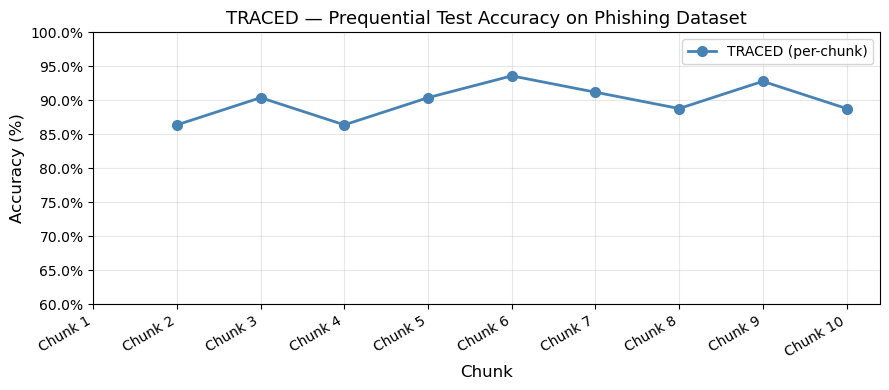

In [53]:
fig, ax = plt.subplots(figsize=(9, 4))
valid_chunks_ph = [i+1 for i, a in enumerate(chunk_accs_ph) if a is not None]
valid_accs_ph   = [a * 100 for a in chunk_accs_ph if a is not None]
ax.plot(valid_chunks_ph, valid_accs_ph,
        marker='o', linewidth=2, markersize=7, color='steelblue', label='TRACED (per-chunk)')
ax.set_xlabel("Chunk", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("TRACED — Prequential Test Accuracy on Phishing Dataset", fontsize=13)
ax.set_xticks(range(1, 11))
ax.set_xticklabels([f"Chunk {i}" for i in range(1, 11)], rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.set_ylim(60, 100)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Resolution Methods: `overlap`, `outside`, `overlap-outside`

TRACED partitions the space around each neuron into three zones:

- **overlap** — a test point lies inside the ellipsoids of two or more classes simultaneously → resolved via PCA projection
- **outside** — a test point lies outside all class ellipsoids → resolved using displacement + expansion
- **overlap-outside** — handles both zones (default)

> **Note:** Outside-region resolution relies on the `displacement` and `expansion` vectors that accumulate
> across incremental updates. It only activates meaningfully when the model has seen **multiple chunks**
> (i.e. `partial_fit` called more than once). A single-batch fit leaves these vectors at zero.

The comparison below trains each classifier incrementally over 4 chunks.

In [62]:
X_bin, y_bin = make_classification(
    n_samples=500, n_features=10, n_informative=5, random_state=42
)
X_tr, X_te = X_bin[:400], X_bin[400:]
y_tr, y_te = y_bin[:400], y_bin[400:]
chunks_bin = [(X_tr[i:i+100], y_tr[i:i+100]) for i in range(0, 400, 100)]  # 4 chunks

methods = ["overlap-outside", "overlap", "outside"]
method_results = {}

print(f"{'method':<22}  {'neurons':>7}  {'accuracy':>9}  {'overlap':>8}  {'outside':>8}")
print("-" * 60)
for method in methods:
    clf_m = TRACED(method=method, reduce_dims=1, beta=0,alpha=0)
    for Xc, yc in chunks_bin:  # incremental — activates displacement / expansion
        clf_m.partial_fit(Xc, yc, classes=np.unique(y_bin))
    preds = clf_m.predict(X_te)
    acc = accuracy_score(y_te, preds)
    method_results[method] = acc
    print(f"{method:<22}  {len(clf_m.neuron_list):>7}  {acc:>9.2%}"
          f"  {clf_m.count_overlap:>8}  {clf_m.count_outside:>8}")

method                  neurons   accuracy   overlap   outside
------------------------------------------------------------
overlap-outside               2     90.00%         4        59
overlap                       2     90.00%         4         0
outside                       2     91.00%         0        59


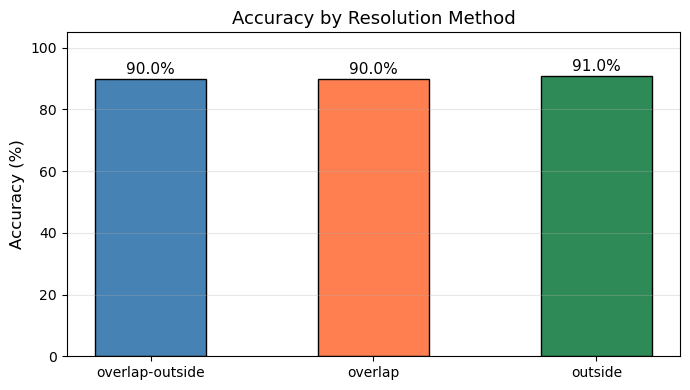

In [63]:
fig, ax = plt.subplots(figsize=(7, 4))
colors_method = ['steelblue', 'coral', 'seagreen']
bars = ax.bar(methods, [method_results[m] * 100 for m in methods],
              color=colors_method, edgecolor='black', width=0.5)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Accuracy by Resolution Method", fontsize=13)
ax.set_ylim(0, 105)
for bar, m in zip(bars, methods):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{method_results[m]:.1%}", ha='center', va='bottom', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Distance Metric: `boundary` vs `center`

- **`boundary`** (default) — measures distance from the ellipsoid boundary (< 0 = inside, > 0 = outside)
- **`center`** — measures normalized Mahalanobis distance from the center (< 0 = inside)

In [64]:
X, y = load_iris(return_X_y=True)
X_tr, X_te, y_tr = X[:120], X[120:], y[:120]

metrics = ["boundary", "center"]
metric_results = {}

print(f"{'distance_metric':<14}  {'neurons':>7}  {'accuracy':>9}")
print("-" * 35)
for metric in metrics:
    clf_d = TRACED(distance_metric=metric)
    clf_d.partial_fit(X_tr, y_tr, classes=np.unique(y))
    acc = accuracy_score(y[120:], clf_d.predict(X_te))
    metric_results[metric] = acc
    print(f"{metric:<14}  {len(clf_d.neuron_list):>7}  {acc:>9.2%}")

distance_metric  neurons   accuracy
-----------------------------------
boundary              7    100.00%
center                7    100.00%


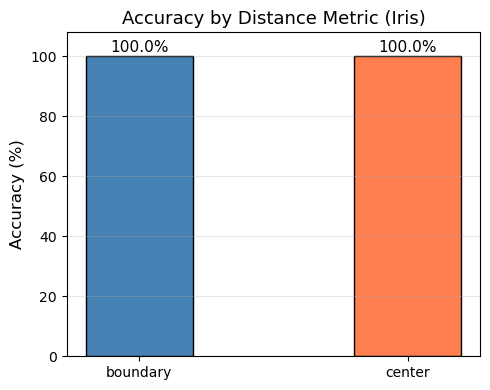

In [65]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(metrics, [metric_results[m] * 100 for m in metrics],
              color=['steelblue', 'coral'], edgecolor='black', width=0.4)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Accuracy by Distance Metric (Iris)", fontsize=13)
ax.set_ylim(0, 108)
for bar, m in zip(bars, metrics):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{metric_results[m]:.1%}", ha='center', va='bottom', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Effect of `N0` — Neuron Eligibility Threshold

`N0` sets the minimum number of training samples a neuron must accumulate before it is eligible to vote in `predict`. This filters out newly created, immature neurons.

In [66]:
n0_values = [1, 3, 5, 10]
n0_results = {}

print(f"{'N0':>4}  {'total neurons':>14}  {'eligible':>9}  {'accuracy':>9}")
print("-" * 42)
for n0 in n0_values:
    clf_n = TRACED(N0=n0)
    clf_n.partial_fit(X_tr, y_tr, classes=np.unique(y))
    eligible = sum(1 for n in clf_n.neuron_list if n['n'] >= n0)
    acc = accuracy_score(y[120:], clf_n.predict(X_te))
    n0_results[n0] = acc
    print(f"{n0:>4}  {len(clf_n.neuron_list):>14}  {eligible:>9}  {acc:>9.2%}")

  N0   total neurons   eligible   accuracy
------------------------------------------
   1               8          8     93.33%
   3               7          4    100.00%
   5               7          4    100.00%
  10               7          3    100.00%


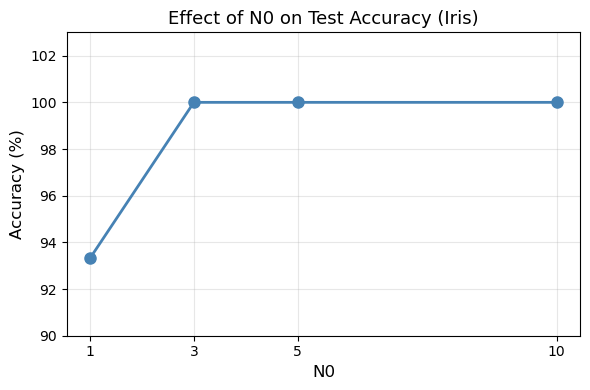

In [67]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(n0_values, [n0_results[n] * 100 for n in n0_values],
        marker='o', linewidth=2, markersize=8, color='steelblue')
ax.set_xlabel("N0", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Effect of N0 on Test Accuracy (Iris)", fontsize=13)
ax.set_xticks(n0_values)
ax.set_ylim(90, 103)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Adaptive Displacement & Expansion: `alpha`, `beta`

- **`alpha`** — smoothing of the `displacement` vector (direction the neuron is moving):
  - `0` = no momentum memory (default)
  - `> 0` = blends in momentum from previous steps; improves handling of outside points

- **`beta`** — smoothing of the `expansion` factor (directional boundary extension):
  - `0` = no accumulated expansion (default)
  - `> 0` = extends the boundary in the direction the neuron has previously grown

In [68]:
configs = [
    {"alpha": 0.0, "beta": 0.0},
    {"alpha": 0.3, "beta": 0.0},
    {"alpha": 0.0, "beta": 0.3},
    {"alpha": 0.3, "beta": 0.3},
]

config_labels = [f"α={c['alpha']}, β={c['beta']}" for c in configs]
config_accs = []

print(f"{'alpha':>6}  {'beta':>6}  {'neurons':>7}  {'accuracy':>9}")
print("-" * 38)
for cfg in configs:
    clf_ab = TRACED(**cfg, method="overlap-outside", reduce_dims=1)
    clf_ab.partial_fit(X_tr, y_tr, classes=np.unique(y))
    acc = accuracy_score(y[120:], clf_ab.predict(X_te))
    config_accs.append(acc)
    print(f"{cfg['alpha']:>6.1f}  {cfg['beta']:>6.1f}  {len(clf_ab.neuron_list):>7}  {acc:>9.2%}")

 alpha    beta  neurons   accuracy
--------------------------------------
   0.0     0.0        7     96.67%
   0.3     0.0        7    100.00%
   0.0     0.3        7    100.00%
   0.3     0.3        7    100.00%


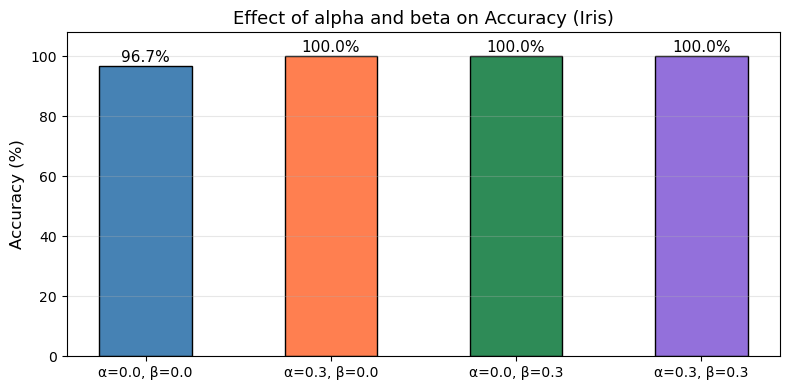

In [69]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(config_labels, [a * 100 for a in config_accs],
              color=['steelblue', 'coral', 'seagreen', 'mediumpurple'],
              edgecolor='black', width=0.5)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Effect of alpha and beta on Accuracy (Iris)", fontsize=13)
ax.set_ylim(0, 108)
for bar, acc in zip(bars, config_accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{acc:.1%}", ha='center', va='bottom', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. High-Dimensional Data — Digits Dataset

Digits: 1,797 samples · **64 features** · 10 classes  
Use `reduce_dims` to drop low-variance PCA axes during overlap resolution.

In [70]:
X_dg, y_dg = load_digits(return_X_y=True)
X_tr_dg, X_te_dg = X_dg[:1200], X_dg[1200:]
y_tr_dg, y_te_dg = y_dg[:1200], y_dg[1200:]

rd_values = [0, 2, 4, 8]
rd_results = {}

print(f"Dataset: {X_dg.shape[0]} samples, {X_dg.shape[1]} features, {len(np.unique(y_dg))} classes\n")
print(f"{'reduce_dims':>12}  {'neurons':>7}  {'accuracy':>9}  {'overlap':>8}  {'outside':>8}")
print("-" * 55)
for rd in rd_values:
    clf_dg = TRACED(method="overlap-outside", reduce_dims=rd, N0=5)
    clf_dg.partial_fit(X_tr_dg, y_tr_dg, classes=np.unique(y_dg))
    acc = accuracy_score(y_te_dg, clf_dg.predict(X_te_dg))
    rd_results[rd] = acc
    print(f"{rd:>12}  {len(clf_dg.neuron_list):>7}  {acc:>9.2%}"
          f"  {clf_dg.count_overlap:>8}  {clf_dg.count_outside:>8}")

Dataset: 1797 samples, 64 features, 10 classes

 reduce_dims  neurons   accuracy   overlap   outside
-------------------------------------------------------
           0       10     89.95%         0       597
           2       10     89.95%         0       597
           4       10     89.95%         0       597
           8       10     89.95%         0       597


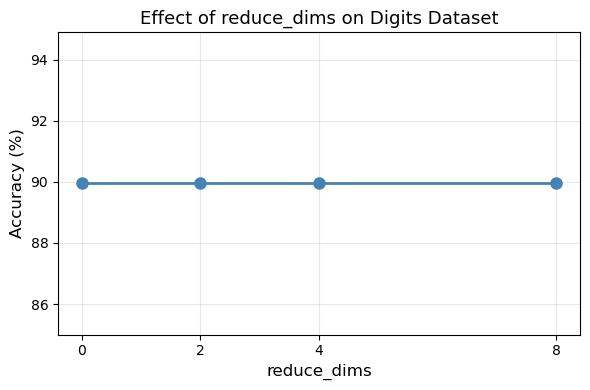

In [71]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rd_values, [rd_results[r] * 100 for r in rd_values],
        marker='o', linewidth=2, markersize=8, color='steelblue')
ax.set_xlabel("reduce_dims", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Effect of reduce_dims on Digits Dataset", fontsize=13)
ax.set_xticks(rd_values)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. sklearn Compatibility

TRACED inherits from `BaseEstimator`, enabling:
- `get_params()` / `set_params()` — inspect and modify hyperparameters
- `clone()` — create an unfitted copy with the same parameter values

In [72]:
original = TRACED(method="overlap", reduce_dims=2, N0=5, alpha=0.2)
original.partial_fit(X_tr, y_tr, classes=np.unique(y))

print("get_params():")
for k, v in original.get_params().items():
    print(f"  {k:<20} = {v}")

print()
cloned = clone(original)
print(f"clone() — unfitted copy:")
print(f"  neuron_list empty : {len(cloned.neuron_list) == 0}")
print(f"  has classes_      : {hasattr(cloned, 'classes_')}")
print(f"  params preserved  : {cloned.get_params() == original.get_params()}")

cloned.partial_fit(X_tr, y_tr, classes=np.unique(y))
acc = accuracy_score(y[120:], cloned.predict(X_te))
print(f"\nclone() after fit:")
print(f"  neurons   : {len(cloned.neuron_list)}")
print(f"  accuracy  : {acc:.2%}")

get_params():
  N0                   = 5
  alpha                = 0.2
  beta                 = 0.01
  delta                = 2
  distance_metric      = boundary
  epsilon              = 1e-10
  method               = overlap
  norm                 = 2
  r                    = 2.5066282746310002
  reduce_dims          = 2
  threshold            = 15
  width_parameter      = 1

clone() — unfitted copy:
  neuron_list empty : True
  has classes_      : False
  params preserved  : True

clone() after fit:
  neurons   : 7
  accuracy  : 96.67%


## 10. Continuous Streaming — Prequential Tracking

Simulates a real data stream using **test-then-train** evaluation:
each chunk is first predicted (test), then used to update the model (train).
`count_overlap` and `count_outside` accumulate throughout the session without resetting.

In [73]:
X_s, y_s = make_classification(n_samples=1000, n_features=8, random_state=0)
chunks_s = [(X_s[i:i+100], y_s[i:i+100]) for i in range(0, 1000, 100)]

clf_s = TRACED(method="overlap-outside", reduce_dims=1)
stream_accs    = []
cum_correct_s  = 0
cum_total_s    = 0

print(f"{'Chunk':>7}  {'Neurons':>7}  {'Accuracy':>9}  {'Cum Acc':>9}  {'Overlap':>8}  {'Outside':>8}")
print("-" * 62)

for i, (Xc, yc) in enumerate(chunks_s):
    if i == 0:
        clf_s.partial_fit(Xc, yc, classes=np.array([0, 1]))
        stream_accs.append(None)
        print(f"{i+1:>5}/10  {len(clf_s.neuron_list):>7}  {'(init)':>9}  {'(init)':>9}"
              f"  {clf_s.count_overlap:>8}  {clf_s.count_outside:>8}")
        continue

    # TEST first
    y_pred = clf_s.predict(Xc)
    acc = np.mean(y_pred == yc)
    cum_correct_s += np.sum(y_pred == yc)
    cum_total_s   += len(yc)
    stream_accs.append(acc)

    # TRAIN after
    clf_s.partial_fit(Xc, yc, classes=np.array([0, 1]))

    print(f"{i+1:>5}/10  {len(clf_s.neuron_list):>7}  {acc:>9.2%}  {cum_correct_s/cum_total_s:>9.2%}"
          f"  {clf_s.count_overlap:>8}  {clf_s.count_outside:>8}")

  Chunk  Neurons   Accuracy    Cum Acc   Overlap   Outside
--------------------------------------------------------------
    1/10        2     (init)     (init)         0         0
    2/10        2     89.00%     89.00%         0        49
    3/10        2     92.00%     90.50%         2        89
    4/10        2     96.00%     92.33%         3       134
    5/10        2     93.00%     92.50%         5       172
    6/10        2     97.00%     93.40%         7       204
    7/10        2     96.00%     93.83%         9       231
    8/10        2     95.00%     94.00%        11       270
    9/10        2     92.00%     93.75%        18       303
   10/10        2     95.00%     93.89%        22       334


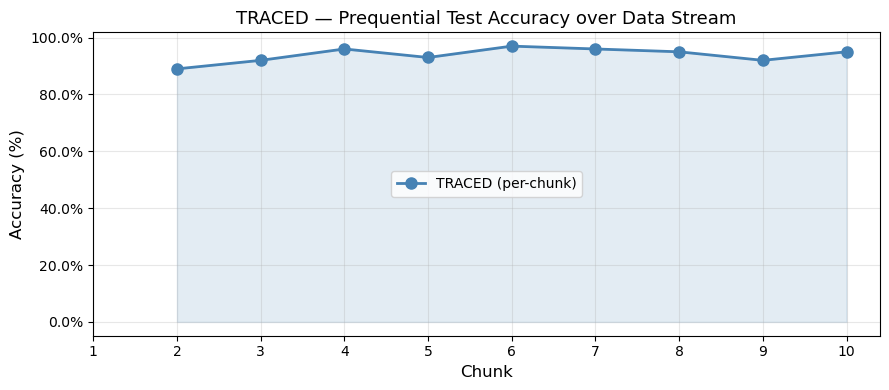

In [74]:
fig, ax = plt.subplots(figsize=(9, 4))
valid_chunks_s = [i+1 for i, a in enumerate(stream_accs) if a is not None]
valid_accs_s   = [a * 100 for a in stream_accs if a is not None]
ax.plot(valid_chunks_s, valid_accs_s,
        marker='o', linewidth=2, markersize=8, color='steelblue', label='TRACED (per-chunk)')
ax.fill_between(valid_chunks_s, valid_accs_s, alpha=0.15, color='steelblue')
ax.set_xlabel("Chunk", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("TRACED — Prequential Test Accuracy over Data Stream", fontsize=13)
ax.set_xticks(range(1, 11))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [75]:
X_s, y_s = make_classification(n_samples=1000, n_features=8, random_state=0)
chunks_s = [(X_s[i:i+100], y_s[i:i+100]) for i in range(0, 1000, 100)]

clf_s = TRACED(method="", reduce_dims=1)
stream_accs    = []
cum_correct_s  = 0
cum_total_s    = 0

print(f"{'Chunk':>7}  {'Neurons':>7}  {'Accuracy':>9}  {'Cum Acc':>9}  {'Overlap':>8}  {'Outside':>8}")
print("-" * 62)

for i, (Xc, yc) in enumerate(chunks_s):
    if i == 0:
        clf_s.partial_fit(Xc, yc, classes=np.array([0, 1]))
        stream_accs.append(None)
        print(f"{i+1:>5}/10  {len(clf_s.neuron_list):>7}  {'(init)':>9}  {'(init)':>9}"
              f"  {clf_s.count_overlap:>8}  {clf_s.count_outside:>8}")
        continue

    # TEST first
    y_pred = clf_s.predict(Xc)
    acc = np.mean(y_pred == yc)
    cum_correct_s += np.sum(y_pred == yc)
    cum_total_s   += len(yc)
    stream_accs.append(acc)

    # TRAIN after
    clf_s.partial_fit(Xc, yc, classes=np.array([0, 1]))

    print(f"{i+1:>5}/10  {len(clf_s.neuron_list):>7}  {acc:>9.2%}  {cum_correct_s/cum_total_s:>9.2%}"
          f"  {clf_s.count_overlap:>8}  {clf_s.count_outside:>8}")

  Chunk  Neurons   Accuracy    Cum Acc   Overlap   Outside
--------------------------------------------------------------
    1/10        2     (init)     (init)         0         0
    2/10        2     89.00%     89.00%         0         0
    3/10        2     93.00%     91.00%         0         0
    4/10        2     96.00%     92.67%         0         0
    5/10        2     93.00%     92.75%         0         0
    6/10        2     97.00%     93.60%         0         0
    7/10        2     95.00%     93.83%         0         0
    8/10        2     95.00%     94.00%         0         0
    9/10        2     92.00%     93.75%         0         0
   10/10        2     94.00%     93.78%         0         0
